NumPy简介5 - 布尔索引与花式索引（文案5对应）
==============

# 第十二章：布尔索引（Boolean Indexing）
试图解决:
- 想按某种条件选数据
- 想不规则地选一些行或列
- 想在高维数组中“精确点选”部分内容
- view 还是 copy

## 12.0 基础索引回顾（快速）

In [ ]:
x = np.arange(24).reshape(4, 6)
print('x.shape =', x.shape)

x.shape = (4, 6)


In [ ]:
print(f"{x[1, 2]=}")
print(f"{x[1].shape=}")
print(f"{x[:, 2:5].shape=}")

x[1, 2]=np.int64(8)
x[1].shape=(6,)
x[:, 2:5].shape=(4, 3)


## 12.1 布尔索引（Boolean Indexing）

### 12.2 mask 与原数组同形状：按条件选像素

img.shape=(600, 800, 3)


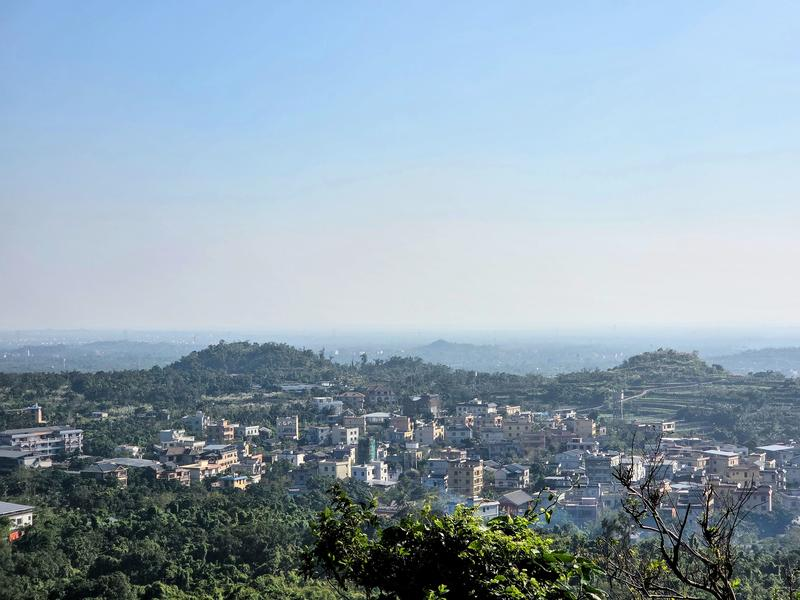

In [ ]:
# 读取图片
img = read_image("/content/drive/MyDrive/Colab Notebooks/Haikou.jpg")
print(f"{img.shape=}")
display_image(img)

img_gray.shape=(600, 800)


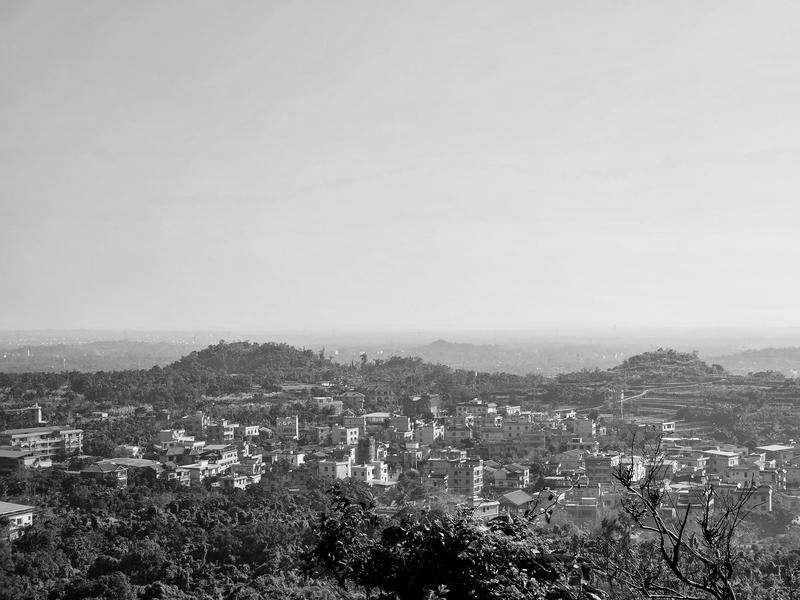

In [ ]:
# 转成黑白图
img_gray = img.mean(axis=2)            # 彩色图片变黑白图: (H,W)
print(f"{img_gray.shape=}")
display_image(img_gray)

mask_dark_area.shape=(600, 800)


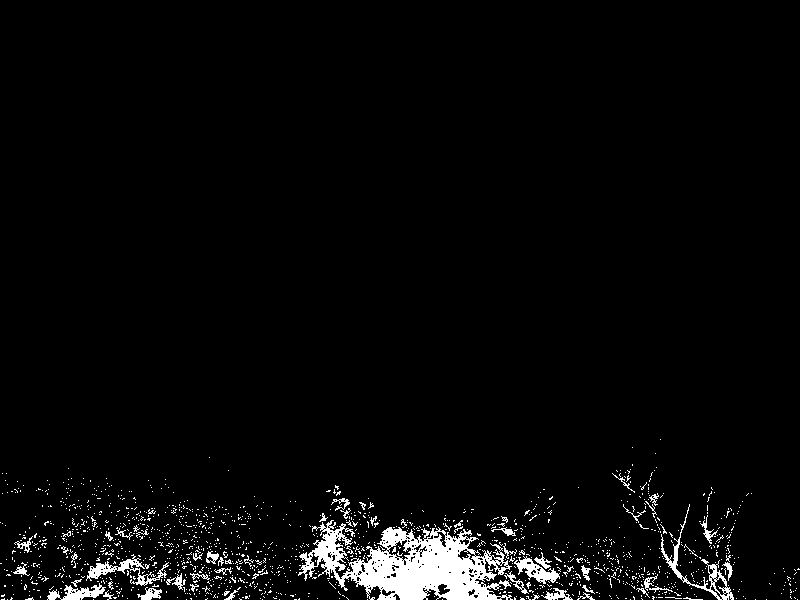

In [ ]:
# 将暗区表示为mask
mask_dark_area = img_gray < 20         # 暗区mask
print(f"{mask_dark_area.shape=}")      # (H, W)
display_image(mask_dark_area)

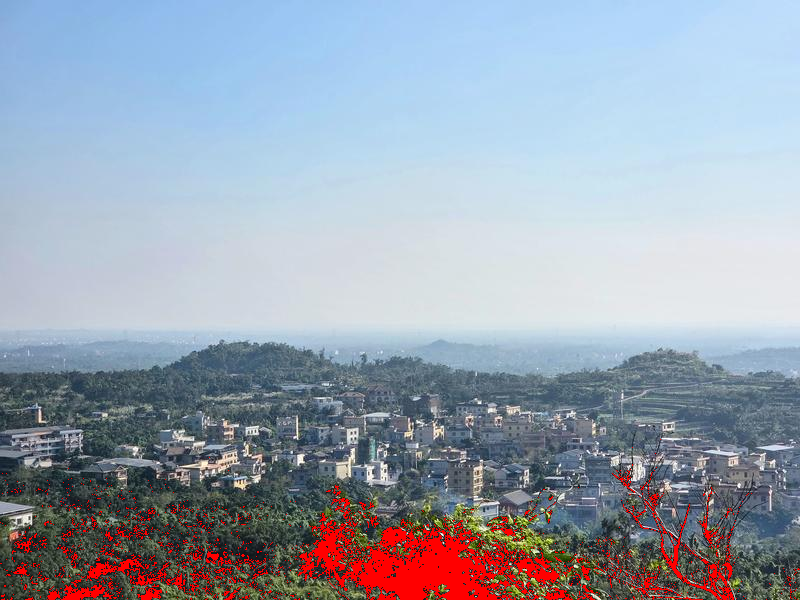

In [ ]:
# 在原图上，将暗区覆盖为红色
overlay = img.copy()
overlay[mask_dark_area] = (255, 0, 0)  # 暗区覆盖为红色
display_image(overlay)

备注：`img[mask]` 本身会返回 shape 为 (num_selected_pixels, 3) 的数组

### 12.3 1D mask 选择指定行/列：去掉天空部分

row_mask.shape=(600,)
rows_picked.shape=(261, 800, 3)


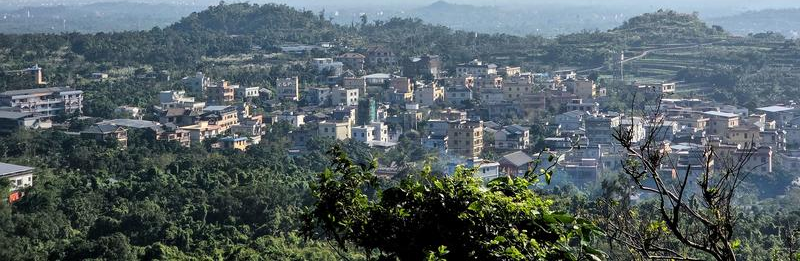

In [ ]:
row_mask = np.mean(img_gray, axis=1) < 200  # 没有那么亮的行是非天空部分
print(f"{row_mask.shape=}")                 # row_mask是1维数组: (H,)

rows_picked = img[row_mask]                 # 只选出这些行（裁掉天空部分）
print(f"{rows_picked.shape=}")              # (num_selected_rows, W, C)
display_image(rows_picked)

# 第十三章：花式索引（Fancy / Integer Array Indexing）

花式索引指的是：使用整数数组作为索引。

In [ ]:
# 随机选择100行
selected_rows = np.sort(np.random.randint(0, img.shape[0], 100))  # 先随机，后排序
print(f"{selected_rows.shape=}")  # (100,)

selected_rows.shape=(100,)


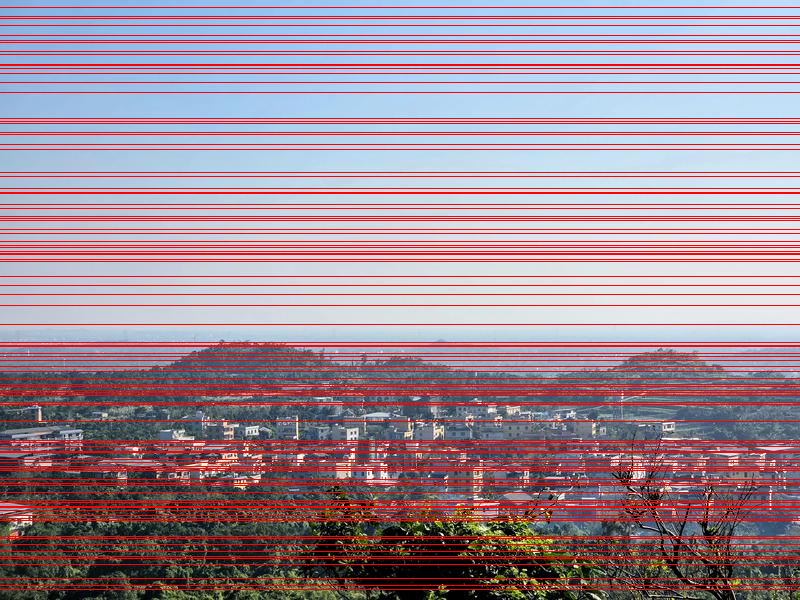

In [ ]:
# 在原始图像上查看这100行
overlay = img.copy()
overlay[selected_rows] = (255, 0, 0)     # 花式索引
display_image(overlay)

selected_img.shape=(100, 800, 3)


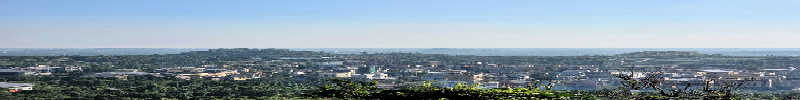

In [ ]:
# 选取这100行:
selected_img = img[selected_rows]  # 花式索引
print(f"{selected_img.shape=}")     # (100, W, C)
display_image(selected_img)        # 拿到选取的行

## 13.2 用 `np.ix_` 做“行列网格采样”

当你同时有 rows 和 cols 时：
- `img[rows, cols]` 的语义是“逐元素配对取点”（常得到一堆像素点）
- `img[np.ix_(rows, cols)]` 的语义是“行列网格”（得到一张新图片）

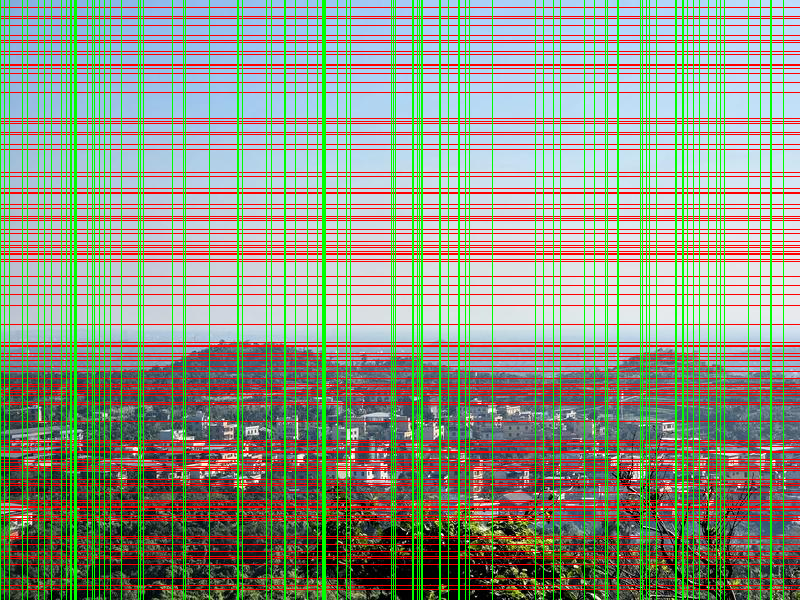

In [ ]:
# 随机选取100列
selected_cols = np.sort(np.random.randint(0, img.shape[1], 100))  # 先随机，后排序

# 同时显示 selected_rows 和 selected_cols
overlay = img.copy()
overlay[selected_rows] = (255, 0, 0)     # 花式索引
overlay[:, selected_cols] = (0, 255, 0)  # 花式索引
display_image(overlay)

selected_img.shape=(100, 100, 3)


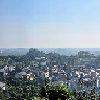

In [ ]:
# 同时索引 selected_rows 和 selected_cols
selected_img = img[np.ix_(selected_rows, selected_cols)]
print(f"{selected_img.shape=}")  # (100, 100, C)
display_image(selected_img)

## 13.5 索引与切片：view 还是 copy？

一般规则:
- 切片一般是view
- 布尔索引、花式索引是copy

更稳妥的判断方式是 `np.shares_memory`：
- True：共享底层内存（基本可以认为是 view）
- False：不共享底层内存（基本可以认为是 copy）

In [ ]:
x = np.arange(12).reshape(3, 4)
slicing = x[:, 1:3]      # 切片
indexing = x[:, [1, 2]]  # 花式索引

print(f"{np.shares_memory(x, slicing)  = }")
print(f"{np.shares_memory(x, indexing) = }")

np.shares_memory(x, slicing)  = True
np.shares_memory(x, indexing) = False


## 13.6 `np.where`：条件选择

### 13.6.1 三参数：按条件在两个值之间选（review）

In [ ]:
x = np.arange(12).reshape(3, 4)
print('x:\n', x)

x:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [ ]:
# 生成mask，模3=0的地方为True
mask = (x % 3 == 0)
print('\nmask:\n', mask)


mask:
 [[ True False False  True]
 [False False  True False]
 [False  True False False]]


In [ ]:
# np.where: True选x，False选-1
y = np.where(mask, x, -1)
print('y:\n', y)

y:
 [[ 0 -1 -1  3]
 [-1 -1  6 -1]
 [-1  9 -1 -1]]


### 13.6.2 一参数：返回满足条件的位置坐标（用于定位）

In [ ]:
idx = np.where(mask)
print(f"{idx=}")
print(f"{x[idx]=}")

idx=(array([0, 0, 1, 2]), array([0, 3, 2, 1]))
x[idx]=array([0, 3, 6, 9])


## 13.7 `take` / `take_along_axis`：沿某个轴按索引取值 (仅了解)

In [ ]:
# np.take()示例:
x = np.arange(24) + 1
idx = [0, 5, 6, 23]
t = np.take(x, idx)
print('take idx ->', t)

take idx -> [ 1  6  7 24]


In [ ]:
# np.take_along_axis示例:
x = np.array([[10, 30, 20],
              [13,  9, 18]])
arg = np.argmax(x, axis=1)          # 每行单独排序(axis=1)，返回每行最大值的列号: (2,)
picked = np.take_along_axis(x, arg[:, None], axis=1) # 第0行取arg[0], 第1行取arg[1]。即拿到最大值。
print('x:\n', x)
print('argmax per row:', arg)
print('picked:\n', picked)
print('picked.shape =', picked.shape)

x:
 [[10 30 20]
 [13  9 18]]
argmax per row: [1 2]
picked:
 [[30]
 [18]]
picked.shape = (2, 1)


## 13.8 小结

- **切片（slice）**：
  - 范围选择
  - 通常共享内存（view）
  - 通常速度最快
- **布尔索引（boolean）**：
  - 按条件筛选；也可用 1D mask 做按行/列选择
  - 通常不共享原数组内存（copy）
  - 通常速度适中
- **花式索引（integer array）**：
  - 显式点选/灵活索引数据
  - 通常不共享原数组内存（copy）
  - 非线性遍历内存
  - 通常速度较慢